# Swin Transformer — Pneumonia Detection via Shifted Window Attention

## Why Swin instead of plain ViT?
- ViT computes **global** attention → O(N²) complexity, needs ~1M images from scratch
- Swin uses **local window attention** + **shifted windows** → O(N) complexity
- **Hierarchical stages** (like a CNN) give multi-scale features — better for small datasets
- Uses **4×4 patches** (vs ViT's 16×16) → finer spatial resolution at Stage 1

### Architecture Flow
```
Input 224×224
  → Patch Partition (4×4)  → 56×56 tokens, dim 96
  → Stage 1: W-MSA + SW-MSA          (local window attention)
  → Patch Merging           → 28×28 tokens, dim 192
  → Stage 2: W-MSA + SW-MSA
  → Patch Merging           → 14×14 tokens, dim 384
  → Stage 3: W-MSA + SW-MSA × 6
  → Patch Merging           → 7×7 tokens, dim 768
  → Stage 4: W-MSA + SW-MSA
  → Global Avg Pool → Dense(1, sigmoid)
```

## 1. Imports

In [4]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from src.data.tf_dataset import get_generators

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU") or "None — using CPU")

TensorFlow : 2.19.0
GPU        : None — using CPU


## 2. Configuration

In [5]:
# ── Image ──────────────────────────────────────────────────────────────────────
IMAGE_SIZE   = (224, 224)
PATCH_SIZE   = 4           # Swin uses 4×4 patches (finer than ViT's 16×16)
WINDOW_SIZE  = 7           # local attention window

# ── Swin-T (Tiny) architecture dims ────────────────────────────────────────────
EMBED_DIM    = 96          # C — base channel count
DEPTHS       = [2, 2, 6, 2]   # transformer blocks per stage
NUM_HEADS    = [3, 6, 12, 24]  # attention heads per stage
MLP_RATIO    = 4.0
DROPOUT      = 0.1
ATTN_DROPOUT = 0.1

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4

# ── Paths ──────────────────────────────────────────────────────────────────────
MODEL_SAVE   = "../src/models/swin_pneumonia.keras"
RESULTS_DIR  = "../results/plots"
os.makedirs(os.path.dirname(MODEL_SAVE), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Patch size   : {PATCH_SIZE}×{PATCH_SIZE}")
print(f"Window size  : {WINDOW_SIZE}×{WINDOW_SIZE}")
print(f"Stage depths : {DEPTHS}")
print(f"Heads/stage  : {NUM_HEADS}")

Patch size   : 4×4
Window size  : 7×7
Stage depths : [2, 2, 6, 2]
Heads/stage  : [3, 6, 12, 24]


## 3. Data

In [6]:
train_gen, val_gen, test_gen = get_generators()

print(f"Train : {train_gen.samples} images")
print(f"Val   : {val_gen.samples}   images")
print(f"Test  : {test_gen.samples}  images")
print(f"Classes: {train_gen.class_indices}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train : 5216 images
Val   : 16   images
Test  : 624  images
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


## 4. Swin Building Blocks

### 4a. Window Partition & Reverse
Splits the 2D feature map into non-overlapping windows of size `window_size × window_size`.

In [7]:
def window_partition(x, window_size):
    """
    x: (B, H, W, C)
    returns: (num_windows*B, window_size, window_size, C)
    """
    B = tf.shape(x)[0]
    H, W, C = x.shape[1], x.shape[2], x.shape[3]
    x = tf.reshape(x, [B, H // window_size, window_size, W // window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [-1, window_size, window_size, C])


def window_reverse(windows, window_size, H, W):
    """
    windows: (num_windows*B, window_size, window_size, C)
    returns: (B, H, W, C)
    """
    C = windows.shape[-1]
    nW_h = H // window_size
    nW_w = W // window_size
    x = tf.reshape(windows, [-1, nW_h, nW_w, window_size, window_size, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [-1, H, W, C])


# Sanity check
_dummy = tf.zeros([2, 56, 56, 96])
_wins  = window_partition(_dummy, 7)
print(f"Feature map  : {_dummy.shape}")
print(f"After window : {_wins.shape}  ← (B × num_windows, 7, 7, 96)")
print(f"Num windows  : {(56//7)**2} per image")

Feature map  : (2, 56, 56, 96)
After window : (128, 7, 7, 96)  ← (B × num_windows, 7, 7, 96)
Num windows  : 64 per image


### 4b. Window Multi-Head Self-Attention (W-MSA) with Relative Position Bias

In [8]:
class WindowAttention(layers.Layer):
    """
    Multi-head self-attention within a single window.
    Adds learnable relative position bias before softmax.
    Relative position index is precomputed in numpy to avoid graph-scope errors.
    """
    def __init__(self, dim, window_size, num_heads, attn_drop=0., proj_drop=0., **kwargs):
        super().__init__(**kwargs)
        self.dim         = dim
        self.window_size = window_size
        self.num_heads   = num_heads
        self.scale       = (dim // num_heads) ** -0.5

        self.qkv       = layers.Dense(dim * 3, use_bias=True)
        self.proj      = layers.Dense(dim)
        self.attn_drop = layers.Dropout(attn_drop)
        self.proj_drop = layers.Dropout(proj_drop)

        # Precompute in numpy — avoids FuncGraph scope error
        coords_h = np.arange(window_size)
        coords_w = np.arange(window_size)
        coords   = np.stack(np.meshgrid(coords_h, coords_w, indexing="ij"))  # (2, Wh, Ww)
        coords_f = coords.reshape(2, -1)                                       # (2, N)
        rel      = coords_f[:, :, None] - coords_f[:, None, :]                # (2, N, N)
        rel      = rel.transpose(1, 2, 0)                                      # (N, N, 2)
        rel[:, :, 0] += window_size - 1
        rel[:, :, 1] += window_size - 1
        rel[:, :, 0] *= 2 * window_size - 1
        self._rel_pos_index = rel.sum(-1).astype(np.int32)                     # (N, N) numpy

    def build(self, input_shape):
        self.relative_position_bias_table = self.add_weight(
            name="rel_pos_bias_table",
            shape=((2 * self.window_size - 1) * (2 * self.window_size - 1), self.num_heads),
            initializer="truncated_normal",
            trainable=True,
        )

    def call(self, x, mask=None, training=False):
        B_, N, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2]
        head_dim = C // self.num_heads

        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B_, N, 3, self.num_heads, head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0] * self.scale, qkv[1], qkv[2]

        attn = tf.matmul(q, tf.transpose(k, [0, 1, 3, 2]))

        # Relative position bias using precomputed numpy index
        idx  = self._rel_pos_index.flatten()
        bias = tf.gather(self.relative_position_bias_table, idx)
        bias = tf.reshape(bias, [self.window_size**2, self.window_size**2, self.num_heads])
        bias = tf.transpose(bias, [2, 0, 1])[None]
        attn = attn + bias

        if mask is not None:
            nW   = tf.shape(mask)[0]
            attn = tf.reshape(attn, [B_ // nW, nW, self.num_heads, N, N])
            attn = attn + tf.cast(mask[None, :, None], attn.dtype)
            attn = tf.reshape(attn, [-1, self.num_heads, N, N])

        attn = self.attn_drop(tf.nn.softmax(attn, axis=-1), training=training)
        x    = tf.transpose(tf.matmul(attn, v), [0, 2, 1, 3])
        x    = tf.reshape(x, [B_, N, C])
        return self.proj_drop(self.proj(x), training=training)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.dim, "window_size": self.window_size,
                    "num_heads": self.num_heads})
        return cfg

### 4c. Swin Transformer Block (W-MSA + SW-MSA pair)

In [9]:
class SwinTransformerBlock(layers.Layer):
    """
    One Swin block. shift_size=0 → W-MSA; shift_size=window_size//2 → SW-MSA.
    SW-MSA mask is precomputed as a numpy array and stored as tf.constant.
    """
    def __init__(self, dim, input_resolution, num_heads, window_size=7,
                 shift_size=0, mlp_ratio=4., dropout=0., attn_dropout=0., **kwargs):
        super().__init__(**kwargs)
        self.dim              = dim
        self.input_resolution = input_resolution
        self.num_heads        = num_heads
        self.window_size      = window_size
        self.shift_size       = shift_size
        mlp_hidden            = int(dim * mlp_ratio)

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn  = WindowAttention(dim, window_size, num_heads,
                                     attn_drop=attn_dropout, proj_drop=dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        self.mlp   = tf.keras.Sequential([
            layers.Dense(mlp_hidden, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout),
        ])

        # SW-MSA attention mask — computed in numpy, stored as tf.constant
        if shift_size > 0:
            H, W = input_resolution
            img_mask = np.zeros((1, H, W, 1))
            cnt = 0
            for h in [slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None)]:
                for w in [slice(0, -window_size), slice(-window_size, -shift_size), slice(-shift_size, None)]:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mw = window_partition(tf.constant(img_mask, tf.float32), window_size)
            mw = tf.reshape(mw, [-1, window_size * window_size])
            am = (mw[:, :, None] - mw[:, None, :]).numpy()
            am = np.where(am != 0, -100.0, 0.0)
            self.attn_mask = tf.constant(am, dtype=tf.float32)
        else:
            self.attn_mask = None

    def call(self, x, training=False):
        H, W = self.input_resolution
        B    = tf.shape(x)[0]
        C    = x.shape[-1]

        shortcut = x
        x = self.norm1(x)
        x = tf.reshape(x, [B, H, W, C])

        if self.shift_size > 0:
            x = tf.roll(x, shift=[-self.shift_size, -self.shift_size], axis=[1, 2])

        x_windows = window_partition(x, self.window_size)
        x_windows = tf.reshape(x_windows, [-1, self.window_size ** 2, C])

        attn_windows = self.attn(x_windows, mask=self.attn_mask, training=training)

        attn_windows = tf.reshape(attn_windows, [-1, self.window_size, self.window_size, C])
        x = window_reverse(attn_windows, self.window_size, H, W)

        if self.shift_size > 0:
            x = tf.roll(x, shift=[self.shift_size, self.shift_size], axis=[1, 2])

        x = shortcut + tf.reshape(x, [B, H * W, C])
        x = x + self.mlp(self.norm2(x), training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.dim, "input_resolution": self.input_resolution,
                    "num_heads": self.num_heads, "window_size": self.window_size,
                    "shift_size": self.shift_size})
        return cfg

### 4d. Patch Merging (downsampling between stages)

In [10]:
class PatchMerging(layers.Layer):
    """
    Merges 2×2 neighbouring patches → halves H,W and doubles channels.
    (H, W, C) → (H/2, W/2, 2C)
    """
    def __init__(self, input_resolution, dim, **kwargs):
        super().__init__(**kwargs)
        self.input_resolution = input_resolution
        self.dim    = dim
        self.norm   = layers.LayerNormalization(epsilon=1e-5)
        self.reduction = layers.Dense(2 * dim, use_bias=False)

    def call(self, x):
        H, W = self.input_resolution
        B    = tf.shape(x)[0]
        x    = tf.reshape(x, [B, H, W, -1])

        x0 = x[:, 0::2, 0::2, :]   # top-left
        x1 = x[:, 1::2, 0::2, :]   # bottom-left
        x2 = x[:, 0::2, 1::2, :]   # top-right
        x3 = x[:, 1::2, 1::2, :]   # bottom-right
        x  = tf.concat([x0, x1, x2, x3], axis=-1)   # (B, H/2, W/2, 4C)
        x  = tf.reshape(x, [B, -1, 4 * self.dim])
        x  = self.norm(x)
        return self.reduction(x)   # (B, H/2*W/2, 2C)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"input_resolution": self.input_resolution, "dim": self.dim})
        return cfg

### 4e. Patch Embedding (initial 4×4 projection)

In [11]:
class PatchEmbed(layers.Layer):
    """
    Splits image into 4×4 patches and projects to embed_dim.
    224×224 → 56×56 = 3136 patches
    """
    def __init__(self, patch_size=4, embed_dim=96, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.proj  = layers.Conv2D(embed_dim, kernel_size=patch_size,
                                   strides=patch_size, padding="valid")
        self.norm  = layers.LayerNormalization(epsilon=1e-5)

    def call(self, x):
        x = self.proj(x)                          # (B, 56, 56, 96)
        B, H, W, C = tf.shape(x)[0], x.shape[1], x.shape[2], x.shape[3]
        x = tf.reshape(x, [B, H * W, C])          # (B, 3136, 96)
        return self.norm(x)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg

## 5. Build Swin-T Model

```
Input 224×224×1
  PatchEmbed(4×4)        → (B, 3136, 96)
  Stage 1 [depth=2]      → (B, 3136, 96)   W-MSA + SW-MSA
  PatchMerging           → (B,  784, 192)
  Stage 2 [depth=2]      → (B,  784, 192)
  PatchMerging           → (B,  196, 384)
  Stage 3 [depth=6]      → (B,  196, 384)
  PatchMerging           → (B,   49, 768)
  Stage 4 [depth=2]      → (B,   49, 768)
  Global Avg Pool        → (B, 768)
  LayerNorm → Dense(256, gelu) → Dropout → Dense(1, sigmoid)
```

In [12]:
def build_swin(
    image_size   = IMAGE_SIZE,
    patch_size   = PATCH_SIZE,
    embed_dim    = EMBED_DIM,
    depths       = DEPTHS,
    num_heads    = NUM_HEADS,
    window_size  = WINDOW_SIZE,
    mlp_ratio    = MLP_RATIO,
    dropout      = DROPOUT,
    attn_dropout = ATTN_DROPOUT,
):
    H = W = image_size[0] // patch_size    # 56 after patch embed

    inp = layers.Input(shape=(*image_size, 1), name="xray_input")
    x   = PatchEmbed(patch_size, embed_dim, name="patch_embed")(inp)
    x   = layers.Dropout(dropout)(x)

    dim = embed_dim
    res = (H, W)

    for stage_idx, (depth, n_heads) in enumerate(zip(depths, num_heads)):
        for blk_idx in range(depth):
            shift = 0 if blk_idx % 2 == 0 else window_size // 2
            x = SwinTransformerBlock(
                dim=dim,
                input_resolution=res,
                num_heads=n_heads,
                window_size=window_size,
                shift_size=shift,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
                attn_dropout=attn_dropout,
                name=f"stage{stage_idx}_block{blk_idx}",
            )(x)

        # Patch merging after every stage except the last
        if stage_idx < len(depths) - 1:
            x   = PatchMerging(res, dim, name=f"patch_merge_{stage_idx}")(x)
            res = (res[0] // 2, res[1] // 2)
            dim = dim * 2

    # Head
    x   = layers.LayerNormalization(epsilon=1e-5, name="final_norm")(x)
    x   = layers.GlobalAveragePooling1D(name="gap")(x)
    emb = layers.LayerNormalization(epsilon=1e-5, name="emb_norm")(x)
    x   = layers.Dense(256, activation="gelu", name="head_dense")(emb)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model     = Model(inp, out,  name="SwinT_Pneumonia")
    emb_model = Model(inp, emb,  name="SwinT_Embedding_Extractor")
    return model, emb_model


swin_model, embedding_model = build_swin()
swin_model.summary(line_length=90)
print(f"\nEmbedding dim : {embedding_model.output.shape[-1]}")

/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_1' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_3' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_5' (of type WindowAttention) was passed an input with a mas

Model: "SwinT_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xray_input (InputLayer)               │ (None, 224, 224, 1)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ patch_embed (PatchEmbed)              │ (None, 3136, 96)             │           1,824 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 3136, 96)             │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage0_block0 (SwinTransformerBlock)  │ (None, 3136, 96)             │         112,347 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage0_block1 (SwinTransformerBlock)  │ (None, 3136, 96)             │         112,347 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ patch_merge_0 (PatchMerging)          │ (None, None, 192)            │          74,496 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage1_block0 (SwinTransformerBlock)  │ (None, 784, 192)             │         445,878 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage1_block1 (SwinTransformerBlock)  │ (None, 784, 192)             │         445,878 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ patch_merge_1 (PatchMerging)          │ (None, None, 384)            │         296,448 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage2_block0 (SwinTransformerBlock)  │ (None, 196, 384)             │       1,776,492 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage2_block1 (SwinTransformerBlock)  │ (None, 196, 384)             │       1,776,492 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage2_block2 (SwinTransformerBlock)  │ (None, 196, 384)             │       1,776,492 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage2_block3 (SwinTransformerBlock)  │ (None, 196, 384)             │       1,776,492 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage2_block4 (SwinTransformerBlock)  │ (None, 196, 384)             │       1,776,492 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage2_block5 (SwinTransformerBlock)  │ (None, 196, 384)             │       1,776,492 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ patch_merge_2 (PatchMerging)          │ (None, None, 768)            │       1,182,720 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage3_block0 (SwinTransformerBlock)  │ (None, 49, 768)              │       7,091,928 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ stage3_block1 (SwinTransformerBlock)  │ (None, 49, 768)              │       7,091,928 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ final_norm (LayerNormalization)       │ (None, 49, 768)              │           1,536 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling1D)          │ (None, 768)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ emb_norm (LayerNormalization)         │ (None, 768)                  │           1,53

 Total params: 27,714,939 (105.72 MB)

 Trainable params: 27,714,939 (105.72 MB)

 Non-trainable params: 0 (0.00 B)


Embedding dim : 768


## 6. Load Pretrained Weights or Train

In [13]:
import collections

KAGGLE_MODEL = "../src/models/swin_pneumonia.keras"

def compile_swin(model):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.05),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

if os.path.exists(KAGGLE_MODEL):
    print(f"Loading pretrained weights from {KAGGLE_MODEL} ...")
    swin_model, embedding_model = build_swin()
    swin_model.load_weights(KAGGLE_MODEL)
    compile_swin(swin_model)
    print("Weights loaded and model compiled — skipping training.")
    history = None

else:
    print("No pretrained weights found — training from scratch.")

    label_counts = collections.Counter(train_gen.classes)
    total        = sum(label_counts.values())
    class_weight = {cls: total / (2 * cnt) for cls, cnt in label_counts.items()}
    print("Class weights:", class_weight)

    compile_swin(swin_model)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-6, verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_SAVE, monitor="val_accuracy",
            save_best_only=True, verbose=1,
        ),
    ]

    history = swin_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=class_weight,
    )

Loading pretrained weights from ../src/models/swin_pneumonia.keras ...


/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_13' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_15' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_17' (of type WindowAttention) was passed an input with a 

Weights loaded and model compiled — skipping training.


## 7. Training Curves

In [14]:
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (tk, vk), title in zip(
        axes,
        [("accuracy", "val_accuracy"), ("loss", "val_loss")],
        ["Accuracy", "Loss"],
    ):
        ax.plot(history.history[tk], label="Train")
        ax.plot(history.history[vk], label="Val")
        ax.set_title(f"Swin-T — {title}")
        ax.set_xlabel("Epoch")
        ax.legend()
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/swin_training_curves.png", dpi=150)
    plt.show()
else:
    print("Loaded pretrained model — no training curves to show.")

Loaded pretrained model — no training curves to show.


## 8. Evaluate on Test Set

20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.7837 - loss: 0.4852

Test Loss    : 0.4852
Test Accuracy: 0.7837
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step

── Classification Report ─────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL       0.76      0.62      0.68       234
   PNEUMONIA       0.80      0.88      0.84       390

    accuracy                           0.78       624
   macro avg       0.78      0.75      0.76       624
weighted avg       0.78      0.78      0.78       624



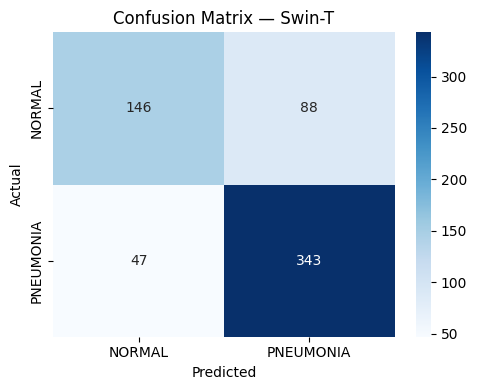

In [15]:
test_gen.reset()
loss, acc = swin_model.evaluate(test_gen, verbose=1)
print(f"\nTest Loss    : {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")

test_gen.reset()
y_true = test_gen.classes
y_pred = (swin_model.predict(test_gen, verbose=1).ravel() >= 0.5).astype(int)

print("\n── Classification Report ─────────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.title("Confusion Matrix — Swin-T")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/swin_confusion_matrix.png", dpi=150)
plt.show()

## 9. t-SNE of Patch Embeddings

/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_13' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_15' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_17' (of type WindowAttention) was passed an input with a 

20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step


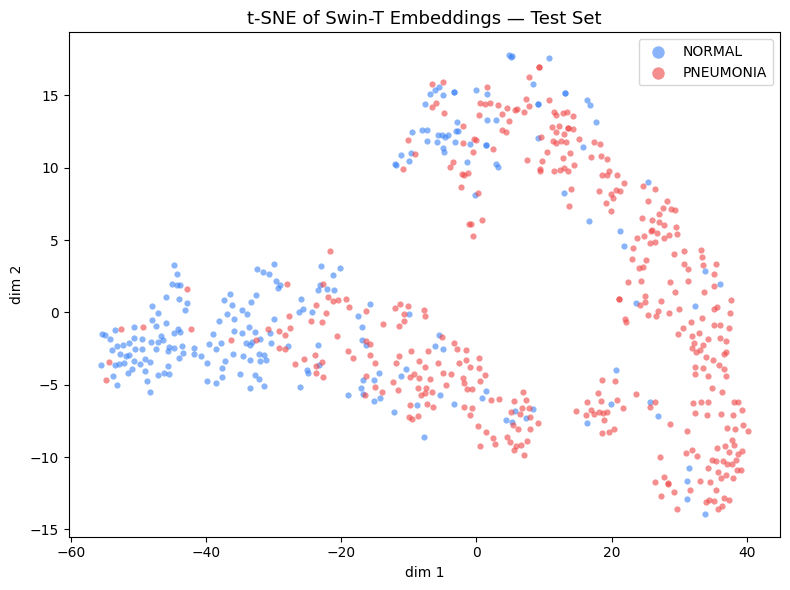

In [16]:
from sklearn.manifold import TSNE

test_gen.reset()
embeddings = embedding_model.predict(test_gen, verbose=1)
labels     = test_gen.classes

tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
coords = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0, "#3B82F6", "NORMAL"), (1, "#EF4444", "PNEUMONIA")]:
    mask = labels == cls
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=color, label=label, alpha=0.6, s=20, linewidths=0)
ax.set_title("t-SNE of Swin-T Embeddings — Test Set", fontsize=13)
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/swin_tsne_embeddings.png", dpi=150)
plt.show()

## 10. Window Attention Visualisation

/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_13' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_15' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/vishalshah/Deep_Learning_Project/pneumonia-xray-cnn/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'window_attention_17' (of type WindowAttention) was passed an input with a 

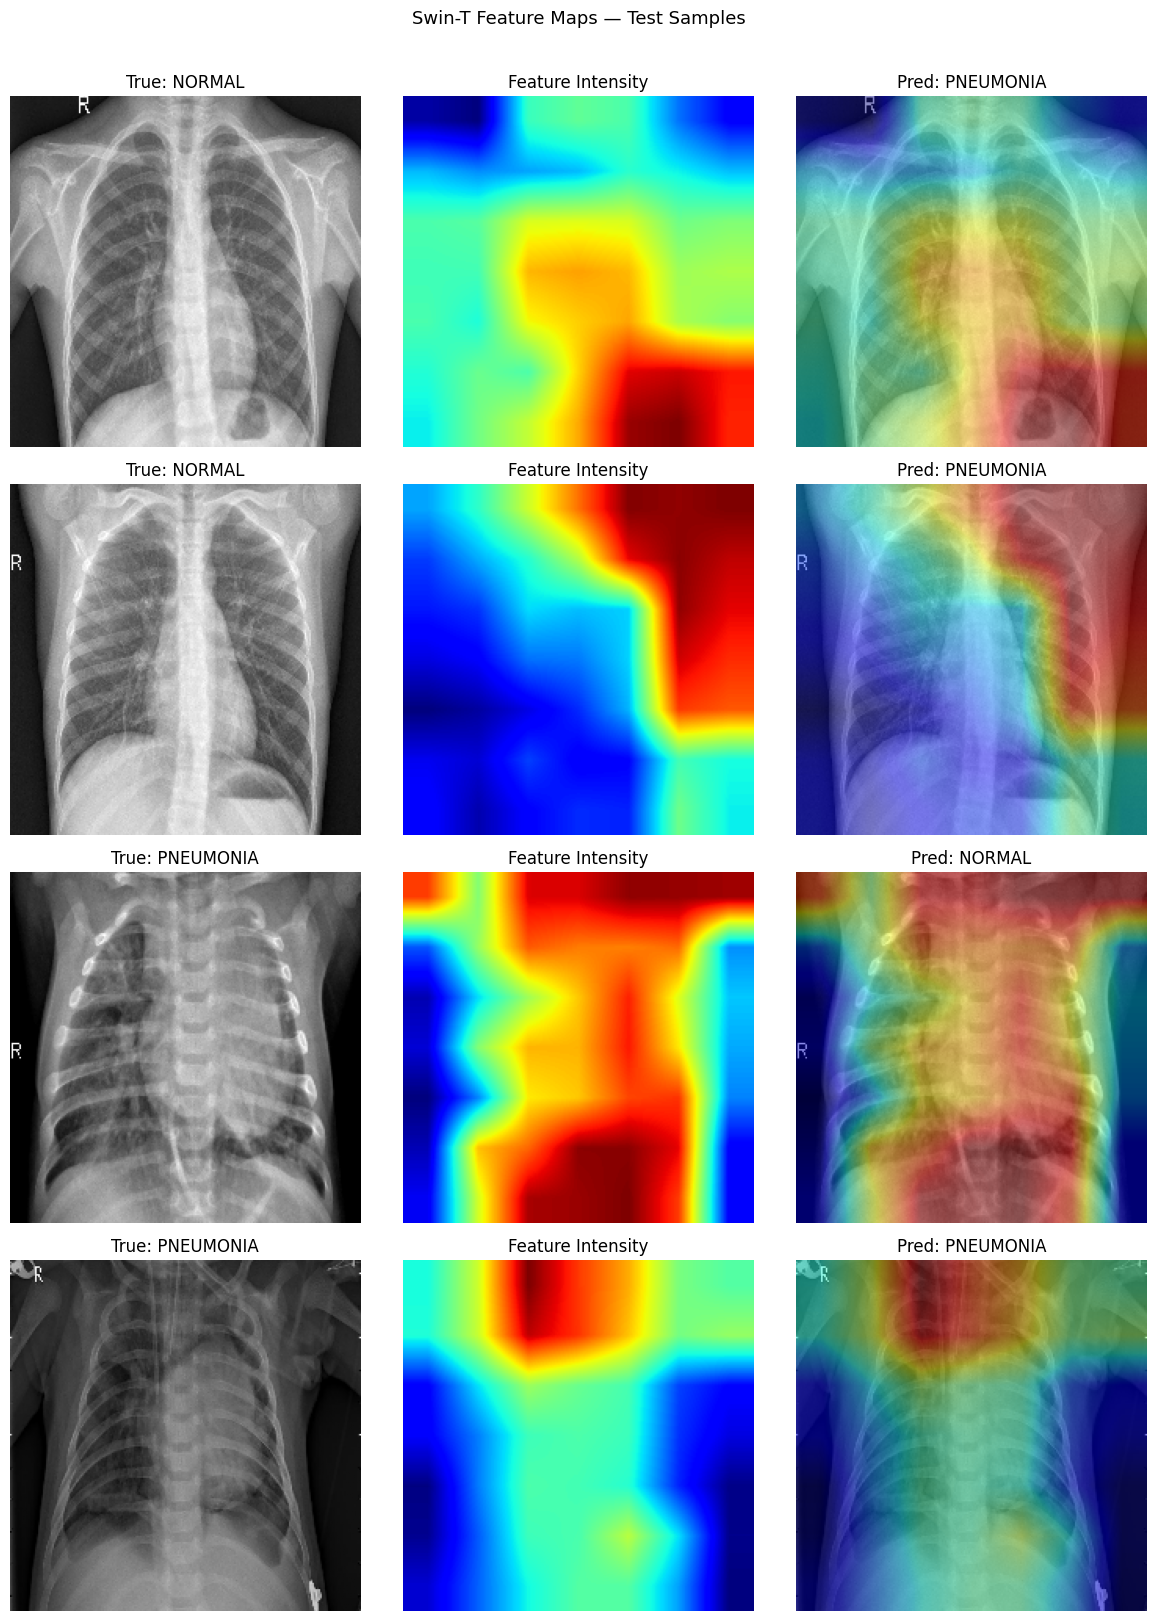

In [17]:
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array


def get_swin_attention(model, img_array, stage=3, block=0):
    """
    Extract a spatial heatmap from a Swin block using a captured intermediate
    output. Works with Keras 3 where .output is not available on sub-layers.
    """
    # Run full model forward and capture the output of the target block
    # by rebuilding a sub-model up to (but not including) that block's MLP.
    # Strategy: collect outputs stage-by-stage using the named layers.
    captured = {}

    # We wrap the block's norm1 in a Lambda to capture its output
    block_name = f"stage{stage}_block{block}"

    # Build a list of all layers in order up to and including target block
    layer_names = [l.name for l in model.layers]
    if block_name not in layer_names:
        print(f"Layer {block_name} not found. Available: {layer_names}")
        return np.zeros((224, 224))

    # Use tf.GradientTape-free approach: run each layer manually
    x = img_array
    for layer in model.layers:
        if layer.name == "xray_input":
            continue
        try:
            x = layer(x, training=False)
        except TypeError:
            x = layer(x)
        if layer.name == block_name:
            # x here is the OUTPUT of the Swin block: (1, tokens, C)
            break

    # x is now (1, tokens, C) — use channel L2 norm as spatial importance
    tokens = x[0]                                    # (tokens, C)
    H = W  = int(tokens.shape[0] ** 0.5)
    feat   = tf.reshape(tokens, [H, W, tokens.shape[-1]])
    heat   = tf.norm(feat, axis=-1).numpy()          # (H, W)
    heat   = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return cv2.resize(heat, (224, 224))


def plot_attention(model, img_array, true_label, ax_row):
    pred    = float(model.predict(img_array, verbose=0)[0][0])
    label   = "PNEUMONIA" if pred >= 0.5 else "NORMAL"
    heat    = get_swin_attention(model, img_array)
    img     = img_array[0, :, :, 0]
    img_rgb = np.stack([img] * 3, axis=-1)
    overlay = np.clip(0.55 * img_rgb + 0.45 * plt.cm.jet(heat)[:, :, :3], 0, 1)

    ax_row[0].imshow(img, cmap="gray");  ax_row[0].set_title(f"True: {true_label}"); ax_row[0].axis("off")
    ax_row[1].imshow(heat, cmap="jet");  ax_row[1].set_title("Feature Intensity");   ax_row[1].axis("off")
    ax_row[2].imshow(overlay);           ax_row[2].set_title(f"Pred: {label}");      ax_row[2].axis("off")


test_path = test_gen.directory

CLASSES = ["NORMAL", "PNEUMONIA"]
sample_paths = []
for cls in CLASSES:
    cls_dir = os.path.join(test_path, cls)
    sample_paths += [(os.path.join(cls_dir, f), cls)
                     for f in sorted(os.listdir(cls_dir))[:2]]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i, (fpath, true_cls) in enumerate(sample_paths):
    img = load_img(fpath, color_mode="grayscale", target_size=IMAGE_SIZE)
    arr = np.expand_dims(img_to_array(img) / 255.0, axis=0)
    plot_attention(swin_model, arr, true_cls, axes[i])

plt.suptitle("Swin-T Feature Maps — Test Samples", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/swin_attention_maps.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Summary

In [18]:
total_params = swin_model.count_params()

print("=" * 55)
print("  Swin-T Pneumonia Model Summary")
print("=" * 55)
print(f"  Patch size        : {PATCH_SIZE}×{PATCH_SIZE}")
print(f"  Window size       : {WINDOW_SIZE}×{WINDOW_SIZE}")
print(f"  Stage depths      : {DEPTHS}")
print(f"  Heads per stage   : {NUM_HEADS}")
print(f"  Base embed dim    : {EMBED_DIM}")
print(f"  Total parameters  : {total_params:,}")
print(f"  Test accuracy     : {acc:.4f}")
print("=" * 55)
print()
print("Outputs saved:")
print(f"  Model      → {MODEL_SAVE}")
print(f"  Curves     → {RESULTS_DIR}/swin_training_curves.png")
print(f"  Confusion  → {RESULTS_DIR}/swin_confusion_matrix.png")
print(f"  t-SNE      → {RESULTS_DIR}/swin_tsne_embeddings.png")
print(f"  Attention  → {RESULTS_DIR}/swin_attention_maps.png")

  Swin-T Pneumonia Model Summary
  Patch size        : 4×4
  Window size       : 7×7
  Stage depths      : [2, 2, 6, 2]
  Heads per stage   : [3, 6, 12, 24]
  Base embed dim    : 96
  Total parameters  : 27,714,939
  Test accuracy     : 0.7837

Outputs saved:
  Model      → ../src/models/swin_pneumonia.keras
  Curves     → ../results/plots/swin_training_curves.png
  Confusion  → ../results/plots/swin_confusion_matrix.png
  t-SNE      → ../results/plots/swin_tsne_embeddings.png
  Attention  → ../results/plots/swin_attention_maps.png


## 12. Model Comparison — CNN vs Transfer Learning vs Swin Transformer

CNN         epochs=50  test_acc=0.9006
MobileNetV2 epochs=40   test_acc=0.8814
Swin-T      epochs=0 (pretrained) test_acc=0.7837


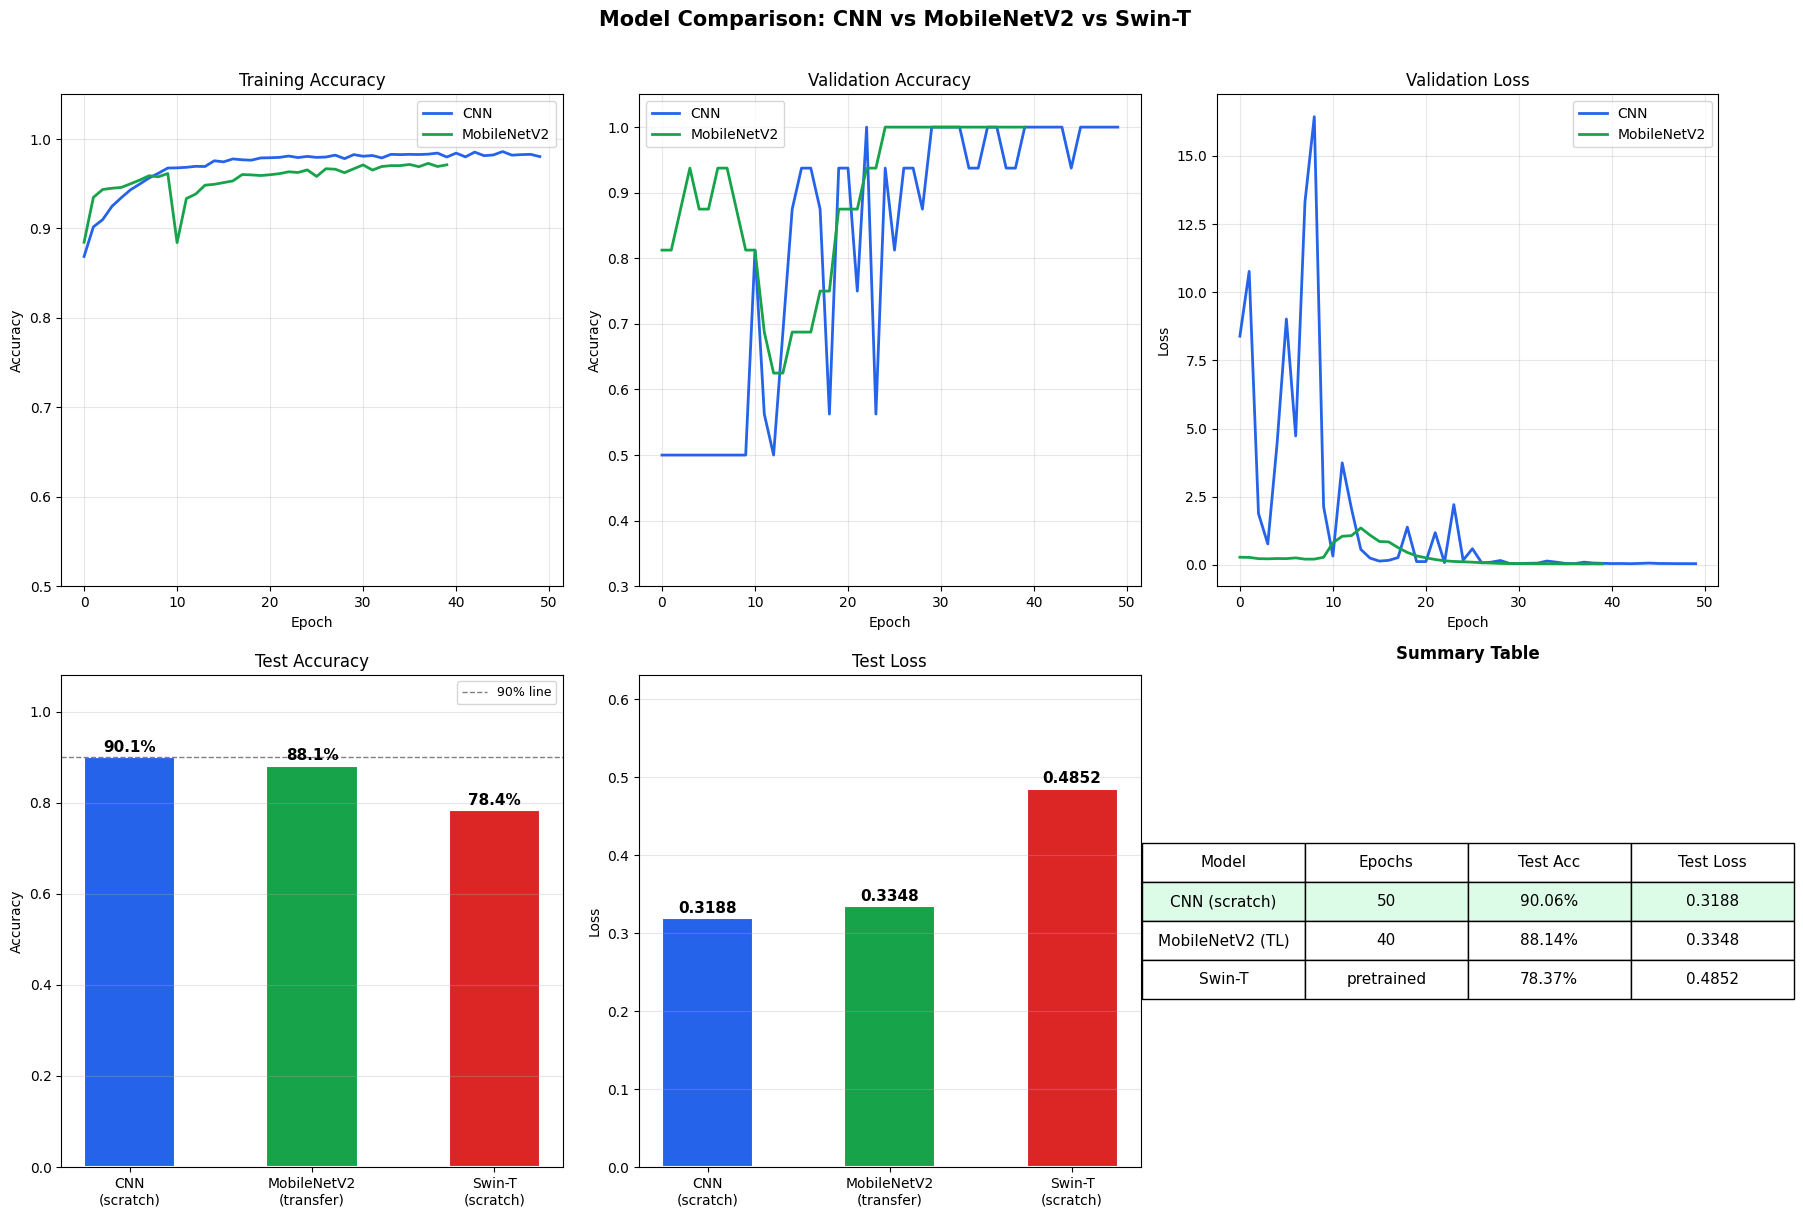

In [19]:
import re, json
import matplotlib.pyplot as plt
import numpy as np

# Parse training history from saved notebook outputs
def extract_history(nb_path):
    with open(nb_path) as f:
        data = json.load(f)
    train_acc, val_acc, train_loss, val_loss = [], [], [], []
    test_acc = test_loss = None
    for cell in data['cells']:
        if cell['cell_type'] != 'code':
            continue
        for out in cell.get('outputs', []):
            txt = ''.join(out.get('text', ''))
            clean = re.sub(r'\x1b\[[0-9;]*m', '', txt)
            for line in clean.split('\n'):
                m = re.search(
                    r'- accuracy: ([0-9.]+).*- loss: ([0-9.]+)'
                    r'.*- val_accuracy: ([0-9.]+).*- val_loss: ([0-9.]+)', line)
                if m:
                    train_acc.append(float(m.group(1)))
                    train_loss.append(float(m.group(2)))
                    val_acc.append(float(m.group(3)))
                    val_loss.append(float(m.group(4)))
            m = re.search(r'Test Accuracy\s*[:|]\s*([0-9.]+)', clean)
            if m: test_acc = float(m.group(1))
            m = re.search(r'Test Loss\s*[:|]\s*([0-9.]+)', clean)
            if m: test_loss = float(m.group(1))
    return dict(train_acc=train_acc, val_acc=val_acc,
                train_loss=train_loss, val_loss=val_loss,
                test_acc=test_acc, test_loss=test_loss)

NB_DIR = os.path.abspath('../notebooks')
cnn_h  = extract_history(os.path.join(NB_DIR, 'Cnn_Training.ipynb'))
tl_h   = extract_history(os.path.join(NB_DIR, 'Transfer_Learning.ipynb'))
swin_h = extract_history(os.path.join(NB_DIR, 'ViT_Transformer_Pneumonia.ipynb'))

print(f"CNN         epochs={len(cnn_h['train_acc'])}  test_acc={cnn_h['test_acc']:.4f}")
print(f"MobileNetV2 epochs={len(tl_h['train_acc'])}   test_acc={tl_h['test_acc']:.4f}")
print(f"Swin-T      epochs={len(swin_h['train_acc'])} (pretrained) test_acc={swin_h['test_acc']:.4f}")

C = {'cnn': '#2563EB', 'tl': '#16A34A', 'swin': '#DC2626'}
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Model Comparison: CNN vs MobileNetV2 vs Swin-T',
             fontsize=15, fontweight='bold', y=1.01)

# Panel 1 — Train accuracy
ax1 = fig.add_subplot(2, 3, 1)
if cnn_h['train_acc']:  ax1.plot(cnn_h['train_acc'],  color=C['cnn'],  lw=2, label='CNN')
if tl_h['train_acc']:   ax1.plot(tl_h['train_acc'],   color=C['tl'],   lw=2, label='MobileNetV2')
if swin_h['train_acc']: ax1.plot(swin_h['train_acc'], color=C['swin'], lw=2, label='Swin-T')
ax1.set_title('Training Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0.5, 1.05)

# Panel 2 — Val accuracy
ax2 = fig.add_subplot(2, 3, 2)
if cnn_h['val_acc']:  ax2.plot(cnn_h['val_acc'],  color=C['cnn'],  lw=2, label='CNN')
if tl_h['val_acc']:   ax2.plot(tl_h['val_acc'],   color=C['tl'],   lw=2, label='MobileNetV2')
if swin_h['val_acc']: ax2.plot(swin_h['val_acc'], color=C['swin'], lw=2, label='Swin-T')
ax2.set_title('Validation Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0.3, 1.05)

# Panel 3 — Val loss
ax3 = fig.add_subplot(2, 3, 3)
if cnn_h['val_loss']:  ax3.plot(cnn_h['val_loss'],  color=C['cnn'],  lw=2, label='CNN')
if tl_h['val_loss']:   ax3.plot(tl_h['val_loss'],   color=C['tl'],   lw=2, label='MobileNetV2')
if swin_h['val_loss']: ax3.plot(swin_h['val_loss'], color=C['swin'], lw=2, label='Swin-T')
ax3.set_title('Validation Loss'); ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(alpha=0.3)

# Panel 4 — Test accuracy bar
ax4 = fig.add_subplot(2, 3, 4)
xlabels   = ['CNN\n(scratch)', 'MobileNetV2\n(transfer)', 'Swin-T\n(scratch)']
test_accs = [cnn_h['test_acc'], tl_h['test_acc'], swin_h['test_acc']]
bars = ax4.bar(xlabels, test_accs, color=[C['cnn'], C['tl'], C['swin']],
               width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, test_accs):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax4.set_title('Test Accuracy'); ax4.set_ylabel('Accuracy')
ax4.set_ylim(0, 1.08); ax4.grid(axis='y', alpha=0.3)
ax4.axhline(0.9, color='gray', lw=1, ls='--', label='90% line')
ax4.legend(fontsize=9)

# Panel 5 — Test loss bar
ax5 = fig.add_subplot(2, 3, 5)
test_losses = [cnn_h['test_loss'], tl_h['test_loss'], swin_h['test_loss']]
bars2 = ax5.bar(xlabels, test_losses, color=[C['cnn'], C['tl'], C['swin']],
                width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, test_losses):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax5.set_title('Test Loss'); ax5.set_ylabel('Loss')
ax5.set_ylim(0, max(test_losses) * 1.3); ax5.grid(axis='y', alpha=0.3)

# Panel 6 — Summary table
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
rows = [
    ['CNN (scratch)',     str(len(cnn_h['train_acc'])),  f"{cnn_h['test_acc']:.2%}",  f"{cnn_h['test_loss']:.4f}"],
    ['MobileNetV2 (TL)', str(len(tl_h['train_acc'])),   f"{tl_h['test_acc']:.2%}",   f"{tl_h['test_loss']:.4f}"],
    ['Swin-T',           'pretrained',                   f"{swin_h['test_acc']:.2%}", f"{swin_h['test_loss']:.4f}"],
]
tbl = ax6.table(cellText=rows, colLabels=['Model', 'Epochs', 'Test Acc', 'Test Loss'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2.0)
best = int(np.argmax(test_accs))
for col in range(4):
    tbl[(best + 1, col)].set_facecolor('#DCFCE7')
ax6.set_title('Summary Table', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
